# ניתוח ימי השבוע של משחקי ליגת העל

מחברת זו בנויה כדי למצות ככל האפשר את שאלת התזמון של משחקי ליגת העל לאורך 20 עונות, על בסיס קובץ המשחקים המתוארך והמעושר מ-Transfermarkt.

המחברת מכסה את הסעיפים הבאים:
1. טעינת ספריות וקריאת הנתונים
2. ניקוי נתונים והמרת תאריכים
3. הפקת מאפייני זמן מהתאריך
4. בניית מדדי בסיס לפי יום בשבוע
5. חישוב ממוצעים פר עונה
6. פילוח משחקים לימי חול מול סוף שבוע
7. התפלגות ימי משחק לפי עונה
8. מדדי שונות, ריכוזיות ויציבות בין עונות
9. מגמות רב-עונתיות לכל יום בשבוע
10. מדדי עומס ורצף משחקים
11. השוואת ימי משחק לפי בית וחוץ
12. השוואת ימי משחק לפי שלב/מסגרת תחרות
13. קורלציות בין יום בשבוע למדדים כמותיים
14. המחשות כמותיות: עמודות, קווים, Heatmap ו-Boxplot
15. טבלת תובנות ומדדים מסכמים לייצוא

הפלטים נשמרים גם כקבצי CSV וגם כגרפים, כדי שאפשר יהיה להשתמש בהם ישירות במאמר או בנספחים.

In [2]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import entropy


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'notebooks' / 'data').exists():
            return candidate
    return current


ROOT = find_project_root()
DATA_DIR = ROOT / 'notebooks' / 'data'
MATCHES_FILE = DATA_DIR / 'matches' / 'matches_all_seasons_ligat_haal_transfermarkt_dated.csv'
ATTENDANCE_FILE = DATA_DIR / 'attendance' / 'attendance_all_seasons_ligat_haal_transfermarkt.csv'
OUTPUT_DIR = DATA_DIR / 'processed' / 'weekday_analysis'
FIGURES_DIR = ROOT / 'notebooks' / 'reports' / 'figures' / 'weekday_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WEEKDAY_ORDER_EN = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
WEEKDAY_ORDER_HE = ['יום שני', 'יום שלישי', 'יום רביעי', 'יום חמישי', 'יום שישי', 'שבת', 'יום ראשון']
WEEKDAY_HE_MAP = dict(zip(WEEKDAY_ORDER_EN, WEEKDAY_ORDER_HE))
WEEKDAY_TYPE_MAP = {
    'Monday': 'weekday',
    'Tuesday': 'weekday',
    'Wednesday': 'weekday',
    'Thursday': 'weekday',
    'Friday': 'weekend',
    'Saturday': 'weekend',
    'Sunday': 'weekday',
}
FOOTBALL_WEEKEND_MAP = {
    'Monday': 'midweek',
    'Tuesday': 'midweek',
    'Wednesday': 'midweek',
    'Thursday': 'midweek',
    'Friday': 'football_weekend',
    'Saturday': 'football_weekend',
    'Sunday': 'football_weekend',
}

HOME_TEAM_TO_ATTENDANCE = {
    'B. Jerusalem': 'Beitar Jerusalem',
    'Bnei Sakhnin': 'Ihud Bnei Sakhnin',
    'Bnei Yehuda': 'Bnei Yehuda Tel Aviv',
    'FC Ashdod': 'FC Ashdod',
    'H Rishon leZion': 'Hapoel Rishon leZion',
    'H. Ashkelon': 'Hapoel Ashkelon',
    'H. Beer Sheva': "Hapoel Be'er Sheva",
    'H. Jerusalem': 'Hapoel Jerusalem',
    'H. Kfar Saba': 'Hapoel Kfar Saba',
    'H. Nof HaGalil': 'Hapoel Nof HaGalil',
    'H. Petah Tikva': 'Hapoel Petah Tikva',
    'H. Ramat Gan': 'Hapoel Ramat Gan',
    'Hakoah Amidar': 'Hakoah Amidar Ramat Gan',
    'Hapoel Acre': 'Hapoel Acre',
    'Hapoel Hadera': 'Hapoel Hadera',
    'Hapoel Haifa': 'Hapoel Haifa',
    'Hapoel Raanana': 'Hapoel Raanana',
    'Hapoel Tel Aviv': 'Hapoel Tel Aviv',
    'Ironi Tiberias': 'Ironi Tiberias',
    'Kiryat Shmona': 'Ironi Kiryat Shmona',
    'M. Ahi Nazareth': 'Maccabi Ahi Nazareth',
    'M. Bnei Reineh': 'Bnei Reineh',
    'M. Petah Tikva': 'Maccabi Petah Tikva',
    'M. Tel Aviv': 'Maccabi Tel Aviv',
    'Maccabi Haifa': 'Maccabi Haifa',
    'Maccabi Herzlya': 'Maccabi Herzliya',
    'Maccabi Netanya': 'Maccabi Netanya',
    'Ness Ziona': 'Sekzia Ness Ziona',
    'Ramat haSharon': 'Hapoel Ramat haSharon',
}


def classify_season_phase(round_value: float, season_rounds: float) -> str:
    if pd.isna(round_value) or pd.isna(season_rounds) or season_rounds <= 0:
        return 'unknown'
    progress = round_value / season_rounds
    if progress <= 1 / 3:
        return 'early_season'
    if progress <= 2 / 3:
        return 'mid_season'
    return 'late_season'


matches_df = pd.read_csv(MATCHES_FILE)
attendance_df = pd.read_csv(ATTENDANCE_FILE)

matches_df = matches_df.drop_duplicates().copy()
matches_df['match_date'] = pd.to_datetime(matches_df['match_date'], errors='coerce')
matches_df = matches_df.dropna(subset=['match_date']).copy()
matches_df['round'] = pd.to_numeric(matches_df['round'], errors='coerce').astype('Int64')
matches_df['round_verified'] = pd.to_numeric(matches_df['round_verified'], errors='coerce').astype('Int64')

score_split = matches_df['score'].astype(str).str.extract(r'(?P<home_goals>\d+)\s*:\s*(?P<away_goals>\d+)')
matches_df['home_goals'] = pd.to_numeric(score_split['home_goals'], errors='coerce')
matches_df['away_goals'] = pd.to_numeric(score_split['away_goals'], errors='coerce')
matches_df['total_goals'] = matches_df['home_goals'] + matches_df['away_goals']
matches_df['goal_diff_abs'] = (matches_df['home_goals'] - matches_df['away_goals']).abs()
matches_df['home_win'] = (matches_df['home_goals'] > matches_df['away_goals']).astype(int)
matches_df['draw'] = (matches_df['home_goals'] == matches_df['away_goals']).astype(int)

matches_df['day_of_week_en'] = pd.Categorical(matches_df['day_of_week_en'], categories=WEEKDAY_ORDER_EN, ordered=True)
matches_df['day_of_week_he'] = matches_df['day_of_week_en'].map(WEEKDAY_HE_MAP)
matches_df['month'] = matches_df['match_date'].dt.month
matches_df['month_name'] = matches_df['match_date'].dt.month_name()
matches_df['calendar_year'] = matches_df['match_date'].dt.year
matches_df['iso_week'] = matches_df['match_date'].dt.isocalendar().week.astype(int)
matches_df['week_start'] = matches_df['match_date'] - pd.to_timedelta(matches_df['match_date'].dt.dayofweek, unit='D')
matches_df['is_weekend'] = matches_df['day_of_week_en'].map(WEEKDAY_TYPE_MAP).eq('weekend')
matches_df['weekday_bucket'] = matches_df['day_of_week_en'].map(WEEKDAY_TYPE_MAP)
matches_df['football_window_bucket'] = matches_df['day_of_week_en'].map(FOOTBALL_WEEKEND_MAP)
matches_df['home_team_attendance_name'] = matches_df['home'].map(HOME_TEAM_TO_ATTENDANCE)

attendance_df['capacity'] = pd.to_numeric(attendance_df['capacity'], errors='coerce')
attendance_df['total_spectators'] = pd.to_numeric(attendance_df['total_spectators'], errors='coerce')
attendance_df['average_attendance'] = pd.to_numeric(attendance_df['average_attendance'], errors='coerce')

matches_df = matches_df.merge(
    attendance_df.rename(columns={'team': 'home_team_attendance_name'}),
    on=['season', 'home_team_attendance_name'],
    how='left',
)
matches_df = matches_df.rename(columns={
    'average_attendance': 'home_team_avg_attendance_proxy',
    'total_spectators': 'home_team_total_spectators_proxy',
    'capacity': 'home_team_capacity_proxy',
    'stadium': 'home_team_stadium_proxy',
})
matches_df['capacity_utilization_proxy_pct'] = (
    matches_df['home_team_avg_attendance_proxy'] / matches_df['home_team_capacity_proxy'] * 100
 )

season_rounds_df = matches_df.groupby('season')['round_verified'].max().rename('season_rounds').reset_index()
matches_df = matches_df.merge(season_rounds_df, on='season', how='left')
matches_df['season_phase'] = matches_df.apply(
    lambda row: classify_season_phase(row['round_verified'], row['season_rounds']),
    axis=1,
 )

sns.set_theme(style='whitegrid', context='talk')

print(f'Total matches loaded: {len(matches_df):,}')
print(f'Seasons covered: {matches_df["season"].nunique()}')
print(f'Date range: {matches_df["match_date"].min().date()} to {matches_df["match_date"].max().date()}')
display(matches_df.head())

Total matches loaded: 3,754
Seasons covered: 20
Date range: 2006-08-26 to 2025-11-29


,round,round_verified,round_original,home,score,away,season,season_year,match_date_raw,match_time_raw,...,weekday_bucket,football_window_bucket,home_team_attendance_name,home_team_stadium_proxy,home_team_capacity_proxy,home_team_total_spectators_proxy,home_team_avg_attendance_proxy,capacity_utilization_proxy_pct,season_rounds,season_phase
0,1,1,1,H. Kfar Saba,4:1,H. Petah Tikva,2006/07,2006,26/08/06,12:00 AM,...,weekend,football_weekend,Hapoel Kfar Saba,Unknown,5800.0,4500.0,2250.0,38.793103,33,early_season
1,1,1,2,M. Petah Tikva,0:0,Hakoah Amidar,2006/07,2006,26/08/06,12:00 AM,...,weekend,football_weekend,Maccabi Petah Tikva,Unknown,11500.0,2000.0,2000.0,17.391304,33,early_season
2,1,1,3,FC Ashdod,1:0,Maccabi Herzlya,2006/07,2006,26/08/06,12:00 AM,...,weekend,football_weekend,FC Ashdod,Unknown,8200.0,2500.0,2500.0,30.487805,33,early_season
3,1,1,4,Maccabi Netanya,3:1,Maccabi Haifa,2006/07,2006,26/08/06,12:00 AM,...,weekend,football_weekend,Maccabi Netanya,Unknown,13610.0,9250.0,3083.0,22.652461,33,early_season
4,1,1,5,M. Tel Aviv,1:2,B. Jerusalem,2006/07,2006,27/08/06,12:00 AM,...,weekday,football_weekend,Maccabi Tel Aviv,Unknown,29150.0,1250.0,1250.0,4.288165,33,early_season


## טבלאות מדדים

הסעיפים הבאים מחשבים את כל טבלאות המדדים העיקריות: שכיחויות בסיסיות, ממוצעים פר עונה, פילוח ימי חול מול סוף שבוע, מדדי פיזור וריכוזיות, מגמות רב-עונתיות, עומס ורצף, פילוחי בית/חוץ, שלב עונה וקשר למדדים כמותיים זמינים.

In [7]:
def normalized_entropy(values: pd.Series) -> float:
    arr = pd.to_numeric(values, errors='coerce').fillna(0).to_numpy(dtype=float)
    arr = arr[arr >= 0]
    total = arr.sum()
    if len(arr) == 0 or np.isclose(total, 0):
        return np.nan
    probs = arr / total
    if len(arr) == 1:
        return 0.0
    return float(entropy(probs) / np.log(len(arr)))


def safe_cv(values: pd.Series) -> float:
    arr = pd.to_numeric(values, errors='coerce').dropna().to_numpy(dtype=float)
    if len(arr) == 0 or np.isclose(arr.mean(), 0):
        return np.nan
    return float(arr.std(ddof=0) / arr.mean())


weekday_sort_map = {day: idx for idx, day in enumerate(WEEKDAY_ORDER_EN)}

overall_weekday_counts_df = (
    matches_df.groupby('day_of_week_en', observed=True).size().rename('matches').reset_index()
    .sort_values('day_of_week_en', key=lambda s: s.map(weekday_sort_map))
    .reset_index(drop=True)
)
overall_weekday_counts_df['day_of_week_he'] = overall_weekday_counts_df['day_of_week_en'].map(WEEKDAY_HE_MAP)
overall_weekday_counts_df['share_pct'] = overall_weekday_counts_df['matches'] / len(matches_df) * 100
overall_weekday_counts_df['rank_by_volume'] = overall_weekday_counts_df['matches'].rank(method='dense', ascending=False).astype(int)

season_weekday_counts_df = (
    matches_df.groupby(['season', 'season_year', 'day_of_week_en'], observed=True).size().reset_index(name='matches')
    .sort_values(['season_year', 'day_of_week_en'], key=lambda s: s.map(weekday_sort_map) if s.name == 'day_of_week_en' else s)
    .reset_index(drop=True)
)
season_weekday_counts_df['day_of_week_he'] = season_weekday_counts_df['day_of_week_en'].map(WEEKDAY_HE_MAP)
season_totals_df = matches_df.groupby(['season', 'season_year'], as_index=False).agg(total_matches=('score', 'count'))
season_weekday_counts_df = season_weekday_counts_df.merge(season_totals_df, on=['season', 'season_year'], how='left')
season_weekday_counts_df['share_pct'] = season_weekday_counts_df['matches'] / season_weekday_counts_df['total_matches'] * 100

season_weekday_pivot_df = (
    season_weekday_counts_df.pivot_table(
        index=['season', 'season_year'],
        columns='day_of_week_en',
        values='matches',
        fill_value=0,
        observed=True,
    )
    .reindex(columns=WEEKDAY_ORDER_EN, fill_value=0)
    .reset_index()
)
season_weekday_share_pivot_df = (
    season_weekday_counts_df.pivot_table(
        index=['season', 'season_year'],
        columns='day_of_week_en',
        values='share_pct',
        fill_value=0,
        observed=True,
    )
    .reindex(columns=WEEKDAY_ORDER_EN, fill_value=0)
    .reset_index()
)

weekday_weekend_summary_df = (
    matches_df.groupby(['season', 'season_year', 'weekday_bucket'], as_index=False)
    .agg(matches=('score', 'count'))
)
weekday_weekend_summary_df = weekday_weekend_summary_df.merge(season_totals_df, on=['season', 'season_year'], how='left')
weekday_weekend_summary_df['share_pct'] = weekday_weekend_summary_df['matches'] / weekday_weekend_summary_df['total_matches'] * 100

football_window_summary_df = (
    matches_df.groupby(['season', 'season_year', 'football_window_bucket'], as_index=False)
    .agg(matches=('score', 'count'))
)
football_window_summary_df = football_window_summary_df.merge(season_totals_df, on=['season', 'season_year'], how='left')
football_window_summary_df['share_pct'] = football_window_summary_df['matches'] / football_window_summary_df['total_matches'] * 100

round_spread_df = (
    matches_df.groupby(['season', 'season_year', 'round_verified'], as_index=False)
    .agg(
        round_matches=('score', 'count'),
        round_days=('match_date', 'nunique'),
        first_date=('match_date', 'min'),
        last_date=('match_date', 'max'),
    )
)
round_spread_df['round_span_days'] = (round_spread_df['last_date'] - round_spread_df['first_date']).dt.days
round_weekend_share_df = (
    matches_df.groupby(['season', 'season_year', 'round_verified'], as_index=False)
    .agg(round_weekend_share_pct=('is_weekend', lambda s: s.mean() * 100))
)
round_spread_df = round_spread_df.merge(round_weekend_share_df, on=['season', 'season_year', 'round_verified'], how='left')

weekly_load_df = (
    matches_df.groupby(['season', 'season_year', 'week_start'], as_index=False)
    .agg(
        weekly_matches=('score', 'count'),
        active_weekdays=('day_of_week_en', 'nunique'),
    )
)

season_gap_df = matches_df.sort_values(['season_year', 'match_date']).copy()
season_gap_df['days_since_prev_match'] = season_gap_df.groupby('season')['match_date'].diff().dt.days

season_summary_df = (
    matches_df.groupby(['season', 'season_year'], as_index=False)
    .agg(
        total_matches=('score', 'count'),
        total_rounds=('round_verified', 'max'),
        unique_weekdays_used=('day_of_week_en', 'nunique'),
        mean_matches_per_round=('round_verified', lambda s: len(s) / s.max()),
        mean_matches_per_week=('week_start', lambda s: len(s) / s.nunique()),
        weekend_share_pct=('is_weekend', lambda s: s.mean() * 100),
        football_weekend_share_pct=('football_window_bucket', lambda s: (s == 'football_weekend').mean() * 100),
        avg_total_goals=('total_goals', 'mean'),
        avg_home_win_rate_pct=('home_win', lambda s: s.mean() * 100),
        avg_draw_rate_pct=('draw', lambda s: s.mean() * 100),
        avg_home_attendance_proxy=('home_team_avg_attendance_proxy', 'mean'),
        avg_capacity_utilization_proxy_pct=('capacity_utilization_proxy_pct', 'mean'),
    )
)

weekday_stats_df = season_weekday_counts_df.groupby(['season', 'season_year']).agg(
    weekday_std=('matches', 'std'),
    weekday_var=('matches', 'var'),
    weekday_range=('matches', lambda s: s.max() - s.min()),
    weekday_cv=('matches', safe_cv),
    weekday_entropy=('matches', normalized_entropy),
    weekday_hhi=('matches', lambda s: float(((s / s.sum()) ** 2).sum()) if s.sum() else np.nan),
    dominant_weekday=('matches', lambda s: season_weekday_counts_df.loc[s.index, 'day_of_week_en'].iloc[s.argmax()]),
    dominant_weekday_share_pct=('share_pct', 'max'),
).reset_index()

round_stats_summary_df = round_spread_df.groupby(['season', 'season_year'], as_index=False).agg(
    avg_days_used_per_round=('round_days', 'mean'),
    median_days_used_per_round=('round_days', 'median'),
    avg_round_span_days=('round_span_days', 'mean'),
    max_round_span_days=('round_span_days', 'max'),
    avg_round_weekend_share_pct=('round_weekend_share_pct', 'mean'),
)

gap_summary_df = season_gap_df.groupby(['season', 'season_year'], as_index=False).agg(
    avg_gap_between_matches=('days_since_prev_match', 'mean'),
    median_gap_between_matches=('days_since_prev_match', 'median'),
    max_gap_between_matches=('days_since_prev_match', 'max'),
)

count_features_df = season_weekday_pivot_df.rename(columns={day: f'count_{day.lower()}' for day in WEEKDAY_ORDER_EN})
share_features_df = season_weekday_share_pivot_df.rename(columns={day: f'share_{day.lower()}_pct' for day in WEEKDAY_ORDER_EN})

season_summary_df = (
    season_summary_df
    .merge(weekday_stats_df, on=['season', 'season_year'], how='left')
    .merge(round_stats_summary_df, on=['season', 'season_year'], how='left')
    .merge(gap_summary_df, on=['season', 'season_year'], how='left')
    .merge(count_features_df, on=['season', 'season_year'], how='left')
    .merge(share_features_df, on=['season', 'season_year'], how='left')
    .sort_values('season_year')
    .reset_index(drop=True)
)

weekday_trends_long_df = season_weekday_counts_df.sort_values(['day_of_week_en', 'season_year']).copy()
weekday_trends_long_df['matches_pct_change'] = weekday_trends_long_df.groupby('day_of_week_en', observed=True)['matches'].pct_change(fill_method=None) * 100
weekday_trends_long_df['share_pct_change'] = weekday_trends_long_df.groupby('day_of_week_en', observed=True)['share_pct'].pct_change(fill_method=None) * 100
weekday_trends_long_df['matches_rolling_mean_3'] = weekday_trends_long_df.groupby('day_of_week_en', observed=True)['matches'].transform(lambda s: s.rolling(3, min_periods=1).mean())

phase_weekday_df = (
    matches_df.groupby(['season_phase', 'day_of_week_en'], observed=True).size().reset_index(name='matches')
    .sort_values(['season_phase', 'day_of_week_en'])
    .reset_index(drop=True)
)
phase_weekday_df['share_within_phase_pct'] = phase_weekday_df.groupby('season_phase')['matches'].transform(lambda s: s / s.sum() * 100)
phase_weekday_df['day_of_week_he'] = phase_weekday_df['day_of_week_en'].map(WEEKDAY_HE_MAP)

club_home_weekday_df = (
    matches_df.groupby(['home', 'day_of_week_en'], observed=True).size().reset_index(name='home_matches')
    .sort_values(['home', 'day_of_week_en'])
    .reset_index(drop=True)
)
club_home_weekday_df['share_within_home_club_pct'] = club_home_weekday_df.groupby('home')['home_matches'].transform(lambda s: s / s.sum() * 100)
club_home_weekday_df['day_of_week_he'] = club_home_weekday_df['day_of_week_en'].map(WEEKDAY_HE_MAP)

weekday_metric_summary_df = (
    matches_df.groupby('day_of_week_en', observed=True, as_index=False)
    .agg(
        matches=('score', 'count'),
        mean_total_goals=('total_goals', 'mean'),
        median_total_goals=('total_goals', 'median'),
        mean_goal_diff_abs=('goal_diff_abs', 'mean'),
        draw_rate_pct=('draw', lambda s: s.mean() * 100),
        home_win_rate_pct=('home_win', lambda s: s.mean() * 100),
        mean_home_attendance_proxy=('home_team_avg_attendance_proxy', 'mean'),
        mean_capacity_utilization_proxy_pct=('capacity_utilization_proxy_pct', 'mean'),
    )
    .sort_values('day_of_week_en', key=lambda s: s.map(weekday_sort_map))
    .reset_index(drop=True)
)
weekday_metric_summary_df['day_of_week_he'] = weekday_metric_summary_df['day_of_week_en'].map(WEEKDAY_HE_MAP)
weekday_metric_summary_df['share_pct'] = weekday_metric_summary_df['matches'] / len(matches_df) * 100

weekday_dummies_df = pd.get_dummies(matches_df['day_of_week_en'], prefix='weekday')
corr_input_df = pd.concat([
    matches_df[['total_goals', 'goal_diff_abs', 'home_win', 'draw', 'home_team_avg_attendance_proxy', 'capacity_utilization_proxy_pct', 'round_verified']],
    weekday_dummies_df,
], axis=1)
correlation_matrix_df = corr_input_df.corr(numeric_only=True)
correlation_focus_df = correlation_matrix_df.loc[[
    'total_goals',
    'goal_diff_abs',
    'home_team_avg_attendance_proxy',
    'capacity_utilization_proxy_pct',
    'round_verified',
], [col for col in correlation_matrix_df.columns if col.startswith('weekday_')]]

summary_export_df = season_summary_df.copy()

overall_weekday_counts_df.to_csv(OUTPUT_DIR / 'weekday_overall_counts.csv', index=False, encoding='utf-8-sig')
season_weekday_counts_df.to_csv(OUTPUT_DIR / 'weekday_season_day_counts_long.csv', index=False, encoding='utf-8-sig')
season_weekday_pivot_df.to_csv(OUTPUT_DIR / 'weekday_season_day_counts_pivot.csv', index=False, encoding='utf-8-sig')
season_weekday_share_pivot_df.to_csv(OUTPUT_DIR / 'weekday_season_day_shares_pivot.csv', index=False, encoding='utf-8-sig')
weekday_weekend_summary_df.to_csv(OUTPUT_DIR / 'weekday_vs_weekend_by_season.csv', index=False, encoding='utf-8-sig')
football_window_summary_df.to_csv(OUTPUT_DIR / 'football_window_by_season.csv', index=False, encoding='utf-8-sig')
round_spread_df.to_csv(OUTPUT_DIR / 'weekday_round_spread_metrics.csv', index=False, encoding='utf-8-sig')
weekly_load_df.to_csv(OUTPUT_DIR / 'weekday_weekly_load_metrics.csv', index=False, encoding='utf-8-sig')
weekday_trends_long_df.to_csv(OUTPUT_DIR / 'weekday_trends_long.csv', index=False, encoding='utf-8-sig')
phase_weekday_df.to_csv(OUTPUT_DIR / 'weekday_phase_distribution.csv', index=False, encoding='utf-8-sig')
club_home_weekday_df.to_csv(OUTPUT_DIR / 'weekday_home_club_distribution.csv', index=False, encoding='utf-8-sig')
weekday_metric_summary_df.to_csv(OUTPUT_DIR / 'weekday_metric_summary.csv', index=False, encoding='utf-8-sig')
correlation_focus_df.to_csv(OUTPUT_DIR / 'weekday_correlation_focus.csv', encoding='utf-8-sig')
summary_export_df.to_csv(OUTPUT_DIR / 'weekday_season_summary_export.csv', index=False, encoding='utf-8-sig')

print('Saved metric tables to:')
print(OUTPUT_DIR)
display(overall_weekday_counts_df)
display(season_summary_df.head())
display(weekday_metric_summary_df)

Saved metric tables to:
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\processed\weekday_analysis


,day_of_week_en,matches,day_of_week_he,share_pct,rank_by_volume
0,Monday,451,יום שני,12.013852,3
1,Tuesday,90,יום שלישי,2.397443,5
2,Wednesday,115,יום רביעי,3.063399,4
3,Thursday,28,יום חמישי,0.745871,6
4,Friday,7,יום שישי,0.186468,7
5,Saturday,2407,שבת,64.118274,1
6,Sunday,656,יום ראשון,17.474694,2


,season,season_year,total_matches,total_rounds,unique_weekdays_used,mean_matches_per_round,mean_matches_per_week,weekend_share_pct,football_weekend_share_pct,avg_total_goals,...,count_friday,count_saturday,count_sunday,share_monday_pct,share_tuesday_pct,share_wednesday_pct,share_thursday_pct,share_friday_pct,share_saturday_pct,share_sunday_pct
0,2006/07,2006,198,33,6,6.0,5.210526,77.777778,93.434343,2.484848,...,2.0,152.0,31.0,5.555556,0.000000,0.505051,0.505051,1.010101,76.767677,15.656566
1,2007/08,2007,198,33,5,6.0,5.657143,80.808081,95.454545,2.318182,...,1.0,159.0,29.0,3.535354,1.010101,0.000000,0.000000,0.505051,80.303030,14.646465
2,2008/09,2008,198,33,4,6.0,5.210526,80.303030,85.858586,2.181818,...,1.0,158.0,11.0,14.141414,0.000000,0.000000,0.000000,0.505051,79.797980,5.555556
3,2009/10,2009,240,30,4,8.0,7.058824,80.833333,90.416667,2.620833,...,0.0,194.0,23.0,9.166667,0.416667,0.000000,0.000000,0.000000,80.833333,9.583333
4,2010/11,2010,240,30,4,8.0,7.058824,75.833333,88.750000,2.587500,...,0.0,182.0,31.0,10.833333,0.000000,0.416667,0.000000,0.000000,75.833333,12.916667


,day_of_week_en,matches,mean_total_goals,median_total_goals,mean_goal_diff_abs,draw_rate_pct,home_win_rate_pct,mean_home_attendance_proxy,mean_capacity_utilization_proxy_pct,day_of_week_he,share_pct
0,Monday,451,2.572062,2.0,1.334812,23.946785,42.572062,8005.776119,34.217879,יום שני,12.013852
1,Tuesday,90,2.422222,2.0,1.466667,20.000000,44.444444,4862.937500,32.856746,יום שלישי,2.397443
2,Wednesday,115,2.634783,2.0,1.365217,25.217391,40.000000,6097.375000,33.361829,יום רביעי,3.063399
3,Thursday,28,2.428571,2.0,1.071429,28.571429,50.000000,5012.518519,25.248170,יום חמישי,0.745871
4,Friday,7,2.142857,2.0,1.000000,57.142857,28.571429,5885.000000,21.091313,יום שישי,0.186468
5,Saturday,2407,2.435397,2.0,1.248857,28.541753,39.717491,4562.473545,30.626018,שבת,64.118274
6,Sunday,656,2.446646,2.0,1.300305,27.439024,38.871951,6222.239203,35.017696,יום ראשון,17.474694


## גרפים כמותיים

התא הבא מייצר סט המחשות רחב: שכיחויות כוללות, heatmap עונות מול ימי שבוע, מגמות עונתיות, מדדי ריכוזיות ופיזור, boxplot לחלוקת הימים, ופילוחים שמטרתם להוציא כמה שיותר תובנות מהשאלה מתי באמת שוחקו המשחקים.

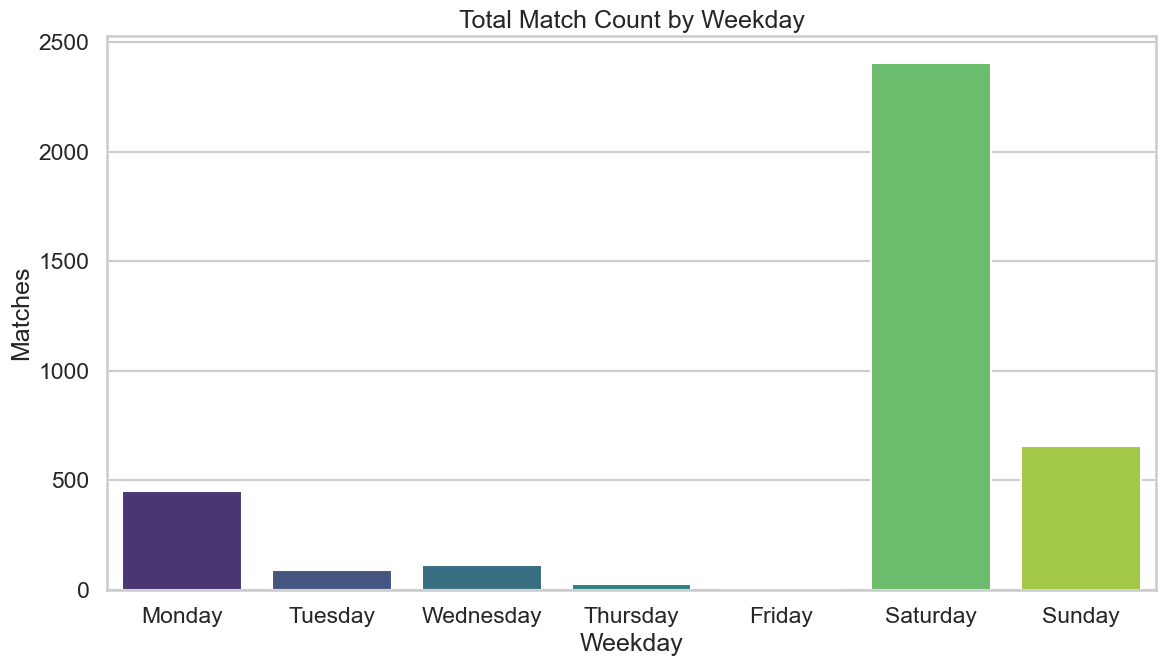

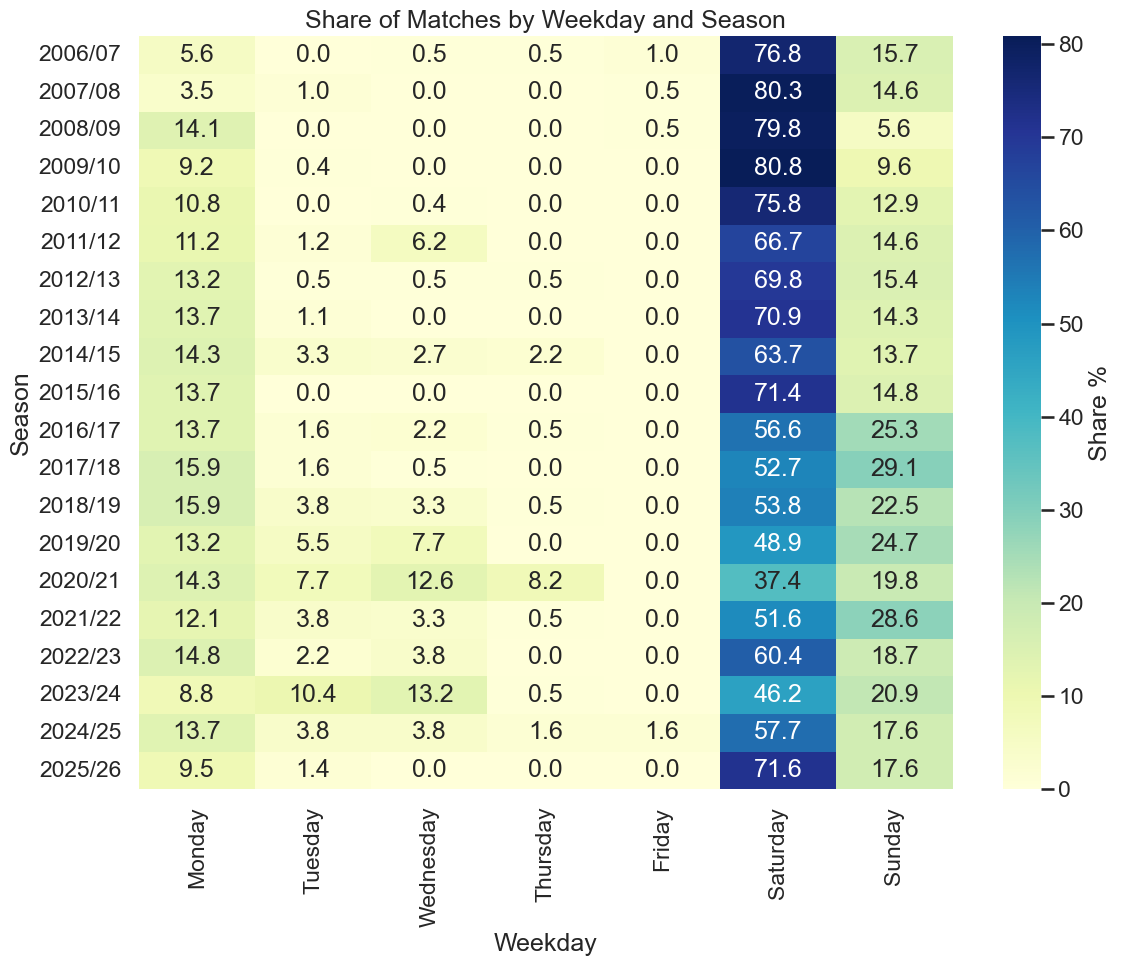

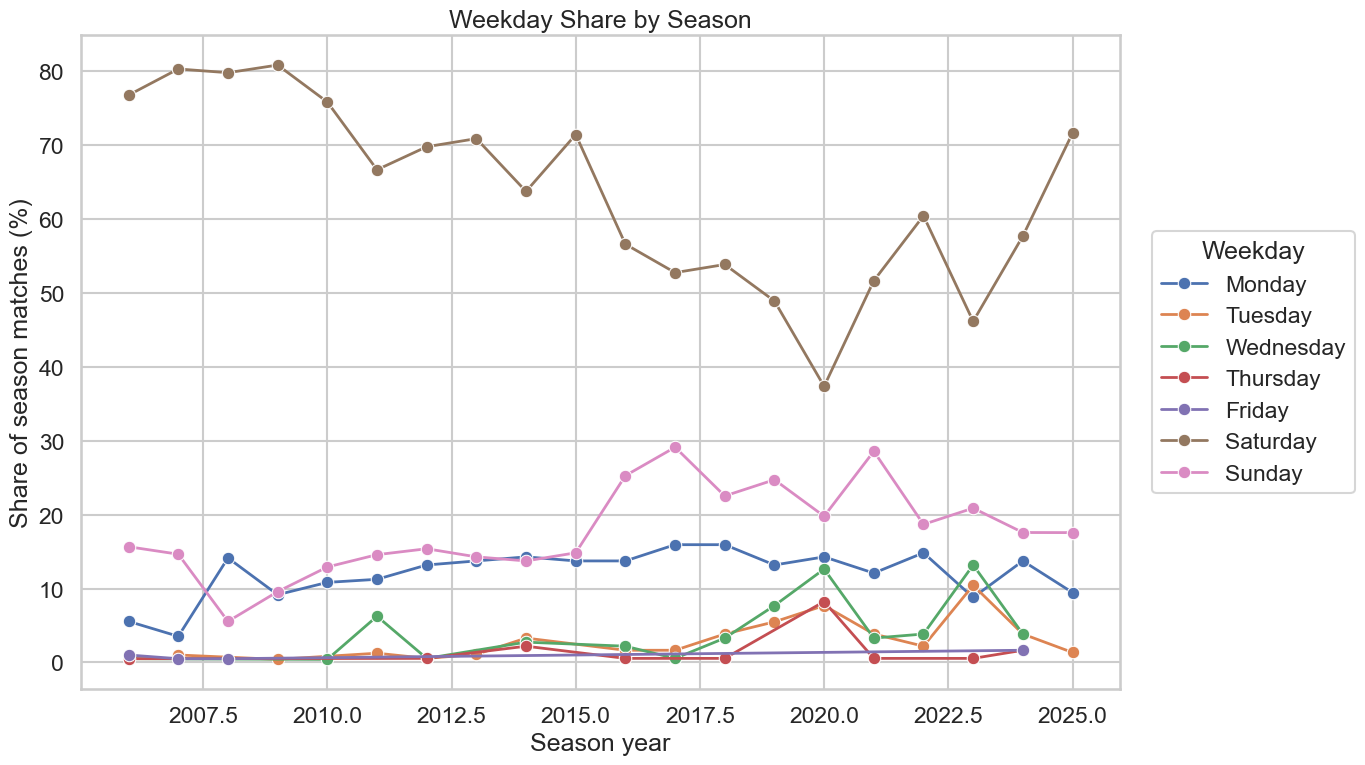

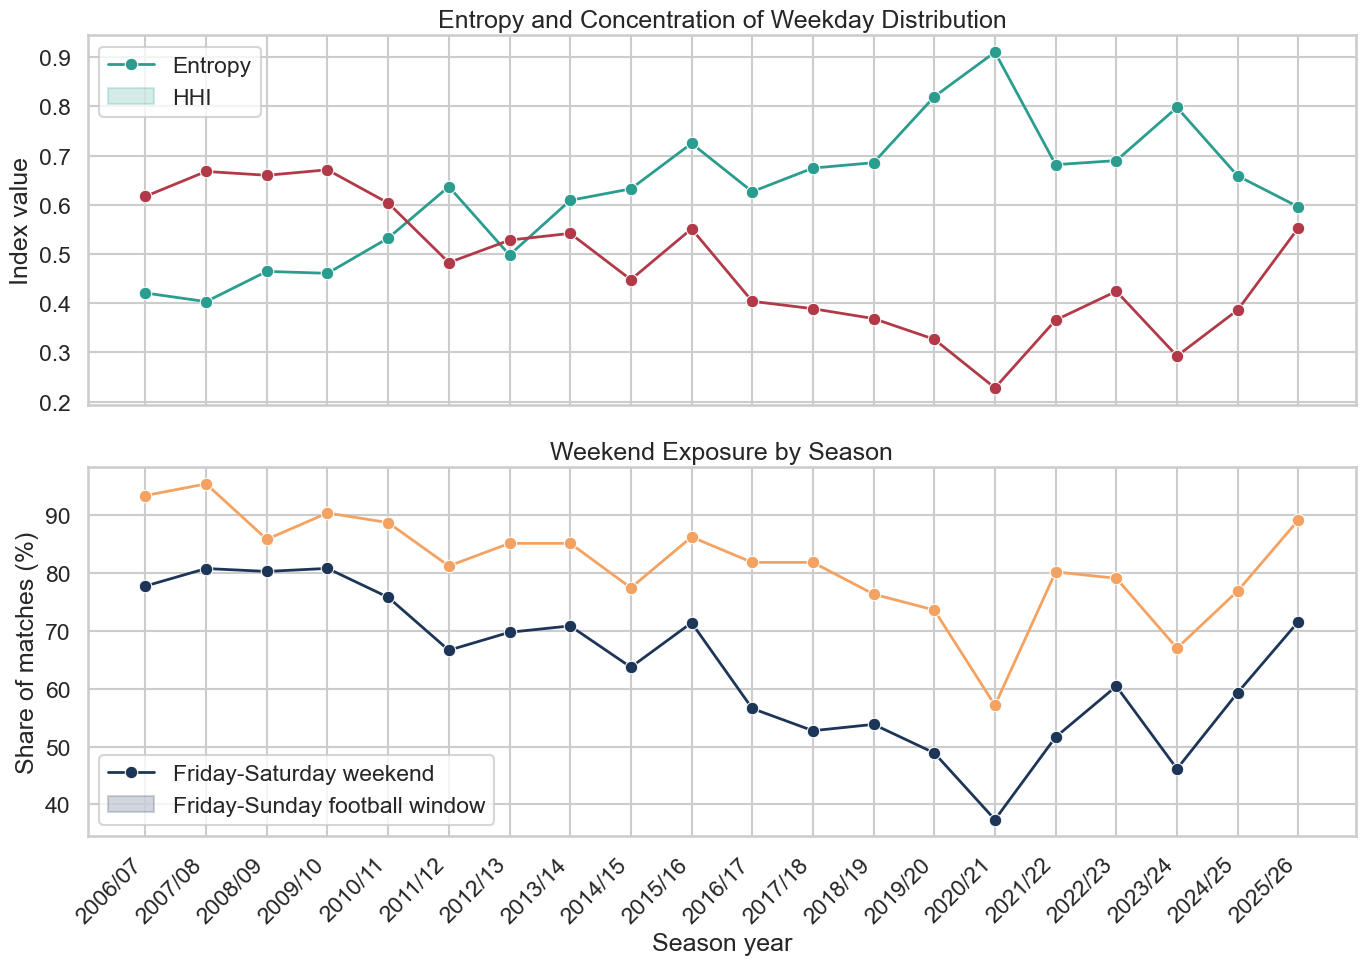

C:\Users\nitib\AppData\Local\Temp\ipykernel_35824\684643458.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=boxplot_df, x='day_of_week_en', y='matches', order=WEEKDAY_ORDER_EN, palette='Set2', ax=ax)


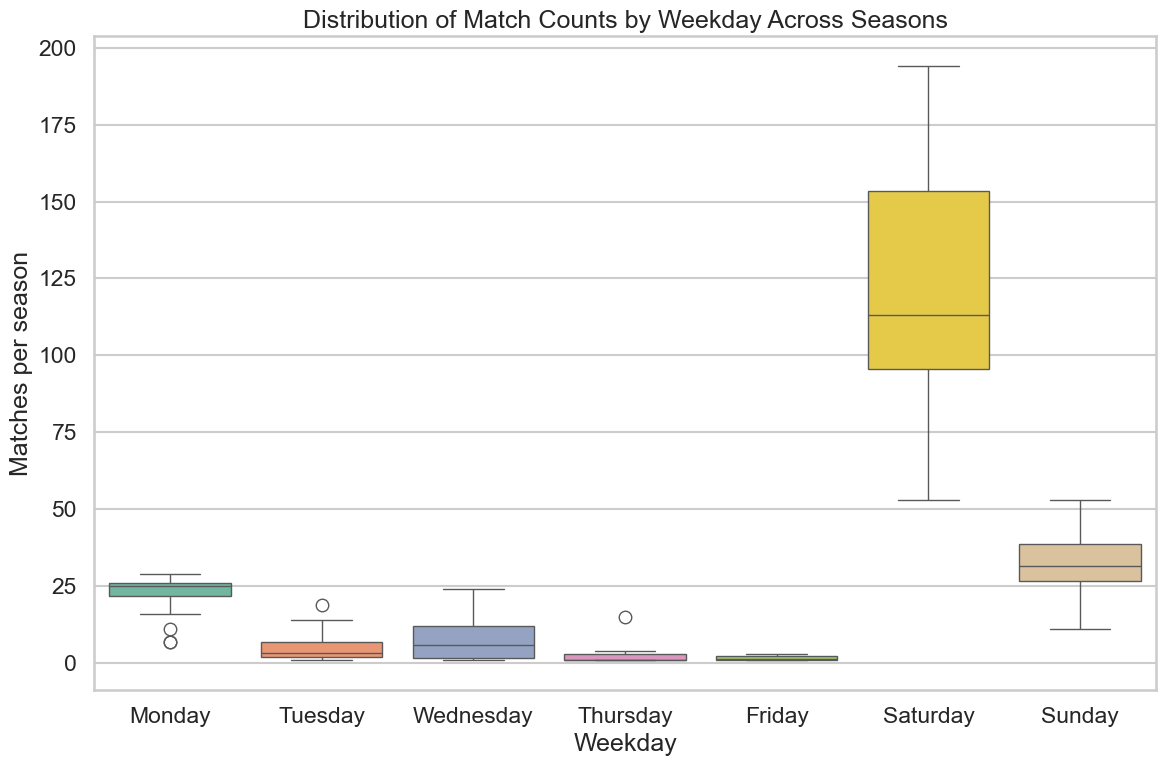

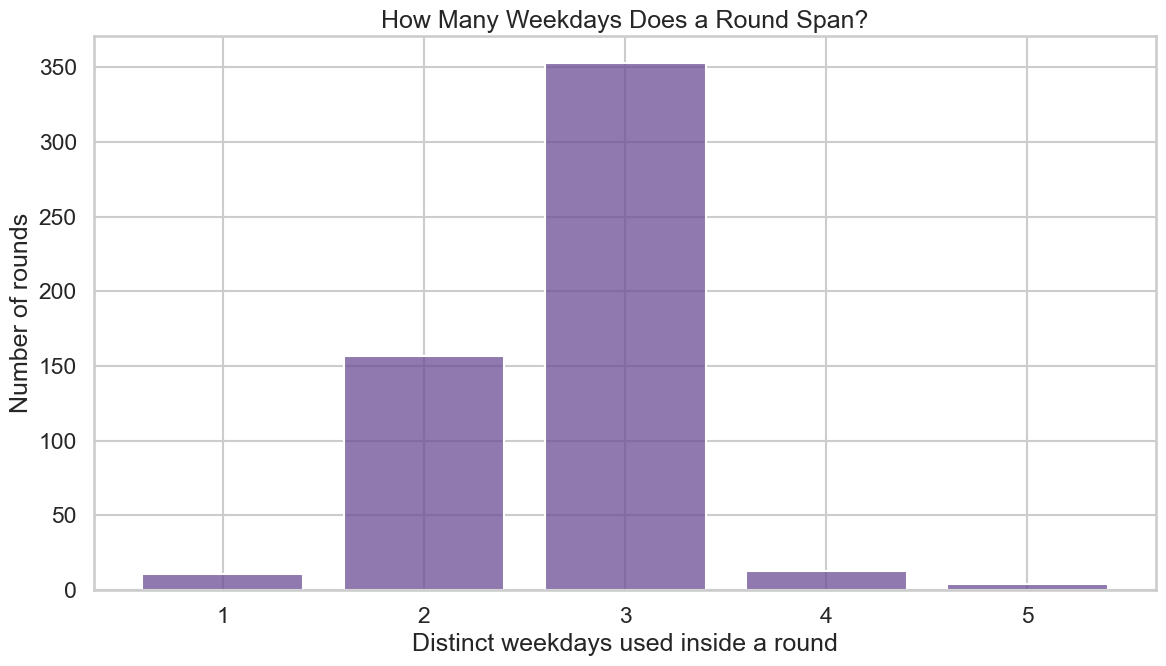

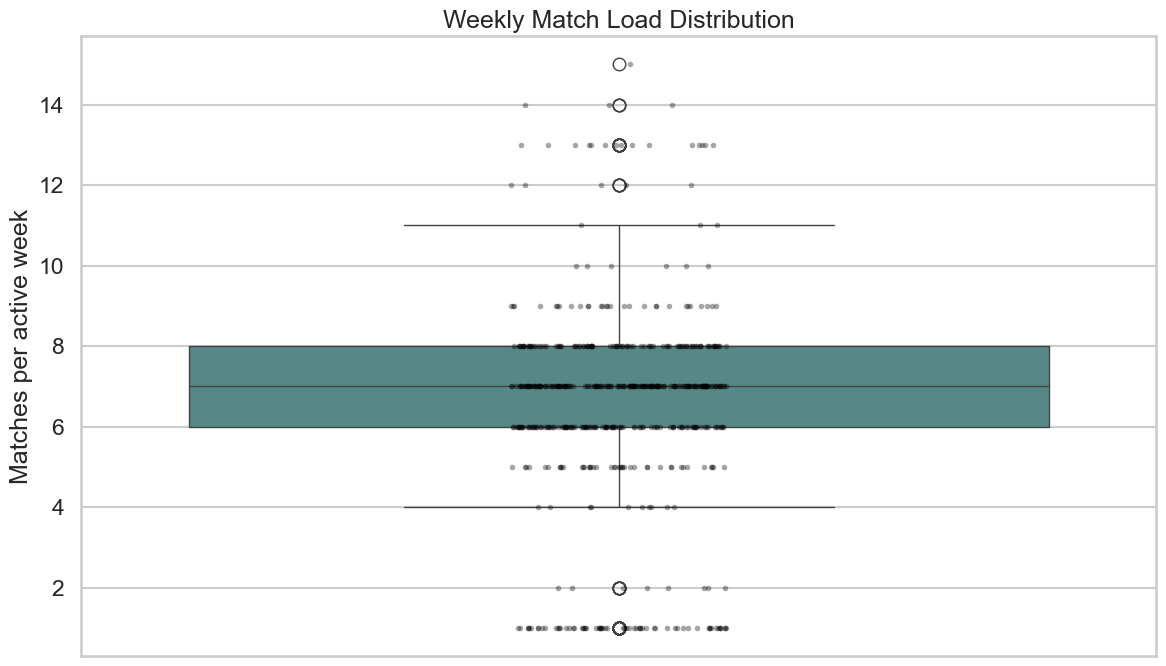

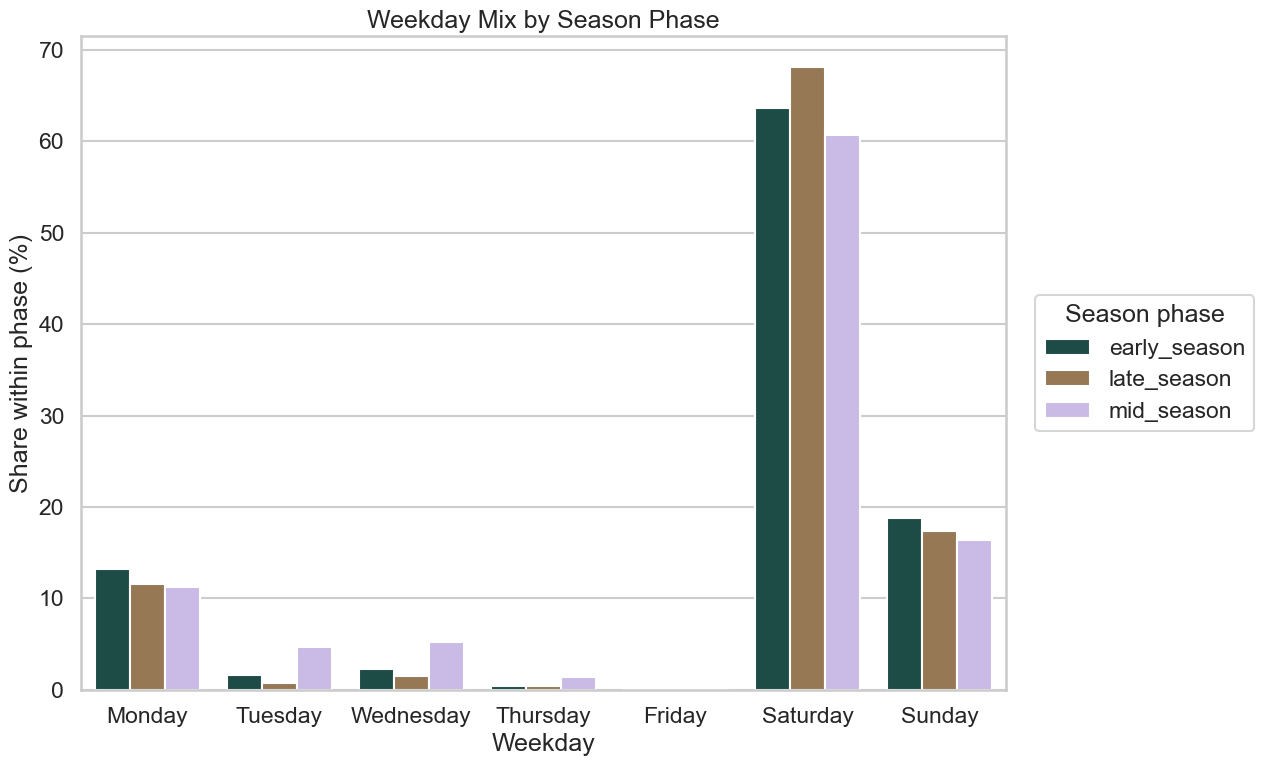

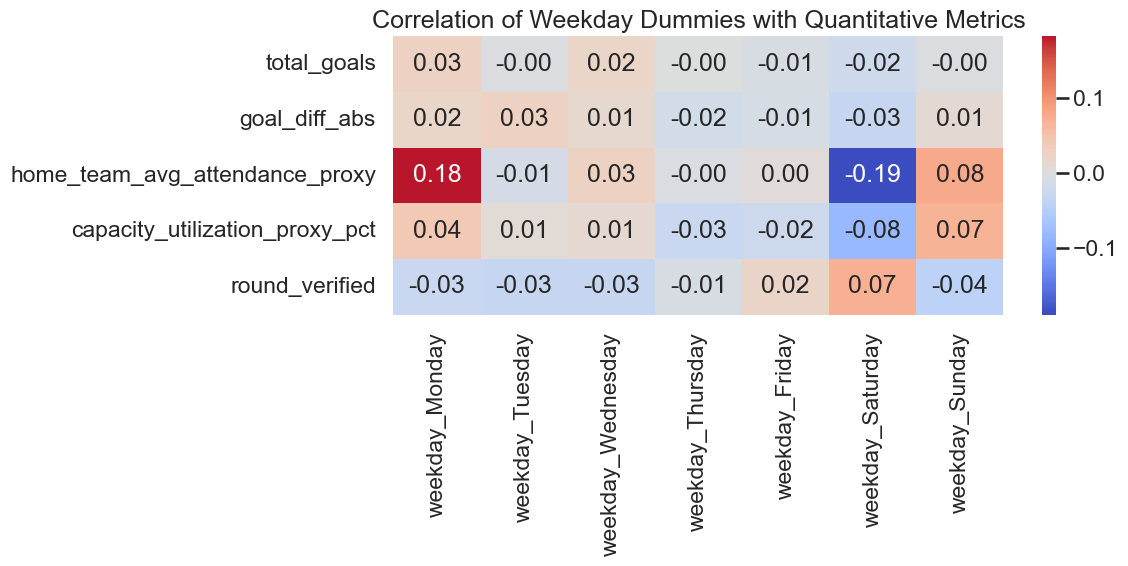

Saved figures to:
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\weekday_analysis\weekday_total_match_count.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\weekday_analysis\weekday_season_heatmap.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\weekday_analysis\weekday_share_trends_by_season.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\weekday_analysis\weekday_concentration_and_weekend_exposure.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\weekday_analysis\weekday_distribution_boxplot.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\weekday_analysis\weekday_round_day_span_histogram.png
C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\reports\figures\weekday_analysis\weekday_weekly_load_boxplot.png
C:\Users\niti

In [8]:
figure_paths = []

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=overall_weekday_counts_df,
    x='day_of_week_en',
    y='matches',
    hue='day_of_week_en',
    dodge=False,
    palette='viridis',
    ax=ax,
 )
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.set_title('Total Match Count by Weekday')
ax.set_xlabel('Weekday')
ax.set_ylabel('Matches')
fig.tight_layout()
path = FIGURES_DIR / 'weekday_total_match_count.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

heatmap_df = season_weekday_share_pivot_df.set_index('season')[WEEKDAY_ORDER_EN]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Share %'}, ax=ax)
ax.set_title('Share of Matches by Weekday and Season')
ax.set_xlabel('Weekday')
ax.set_ylabel('Season')
fig.tight_layout()
path = FIGURES_DIR / 'weekday_season_heatmap.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

trend_plot_df = weekday_trends_long_df.copy()
fig, ax = plt.subplots(figsize=(14, 8))
sns.lineplot(
    data=trend_plot_df,
    x='season_year',
    y='share_pct',
    hue='day_of_week_en',
    marker='o',
    linewidth=2,
    ax=ax,
 )
ax.set_title('Weekday Share by Season')
ax.set_xlabel('Season year')
ax.set_ylabel('Share of season matches (%)')
ax.legend(title='Weekday', loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
path = FIGURES_DIR / 'weekday_share_trends_by_season.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

concentration_plot_df = season_summary_df[['season', 'season_year', 'weekday_entropy', 'weekday_hhi', 'weekend_share_pct', 'football_weekend_share_pct']].copy()
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.lineplot(data=concentration_plot_df, x='season_year', y='weekday_entropy', marker='o', linewidth=2, color='#2a9d8f', ax=axes[0])
sns.lineplot(data=concentration_plot_df, x='season_year', y='weekday_hhi', marker='o', linewidth=2, color='#b23a48', ax=axes[0])
axes[0].set_title('Entropy and Concentration of Weekday Distribution')
axes[0].set_ylabel('Index value')
axes[0].legend(['Entropy', 'HHI'])
sns.lineplot(data=concentration_plot_df, x='season_year', y='weekend_share_pct', marker='o', linewidth=2, color='#1d3557', ax=axes[1])
sns.lineplot(data=concentration_plot_df, x='season_year', y='football_weekend_share_pct', marker='o', linewidth=2, color='#f4a261', ax=axes[1])
axes[1].set_title('Weekend Exposure by Season')
axes[1].set_xlabel('Season year')
axes[1].set_ylabel('Share of matches (%)')
axes[1].legend(['Friday-Saturday weekend', 'Friday-Sunday football window'])
axes[1].set_xticks(concentration_plot_df['season_year'])
axes[1].set_xticklabels(concentration_plot_df['season'], rotation=45, ha='right')
fig.tight_layout()
path = FIGURES_DIR / 'weekday_concentration_and_weekend_exposure.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

boxplot_df = season_weekday_counts_df.copy()
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=boxplot_df, x='day_of_week_en', y='matches', order=WEEKDAY_ORDER_EN, palette='Set2', ax=ax)
ax.set_title('Distribution of Match Counts by Weekday Across Seasons')
ax.set_xlabel('Weekday')
ax.set_ylabel('Matches per season')
fig.tight_layout()
path = FIGURES_DIR / 'weekday_distribution_boxplot.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

round_days_plot_df = round_spread_df.copy()
fig, ax = plt.subplots(figsize=(12, 7))
sns.histplot(data=round_days_plot_df, x='round_days', discrete=True, shrink=0.8, color='#6a4c93', ax=ax)
ax.set_title('How Many Weekdays Does a Round Span?')
ax.set_xlabel('Distinct weekdays used inside a round')
ax.set_ylabel('Number of rounds')
fig.tight_layout()
path = FIGURES_DIR / 'weekday_round_day_span_histogram.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

weekly_load_plot_df = weekly_load_df.copy()
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=weekly_load_plot_df, y='weekly_matches', color='#4d908e', ax=ax)
sns.stripplot(data=weekly_load_plot_df, y='weekly_matches', color='black', alpha=0.35, size=4, ax=ax)
ax.set_title('Weekly Match Load Distribution')
ax.set_ylabel('Matches per active week')
ax.set_xlabel('')
fig.tight_layout()
path = FIGURES_DIR / 'weekday_weekly_load_boxplot.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

phase_plot_df = phase_weekday_df.copy()
fig, ax = plt.subplots(figsize=(13, 8))
sns.barplot(data=phase_plot_df, x='day_of_week_en', y='share_within_phase_pct', hue='season_phase', palette='cubehelix', ax=ax)
ax.set_title('Weekday Mix by Season Phase')
ax.set_xlabel('Weekday')
ax.set_ylabel('Share within phase (%)')
ax.legend(title='Season phase', loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
path = FIGURES_DIR / 'weekday_phase_mix.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

corr_plot_df = correlation_focus_df.copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_plot_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation of Weekday Dummies with Quantitative Metrics')
fig.tight_layout()
path = FIGURES_DIR / 'weekday_metric_correlations_heatmap.png'
fig.savefig(path, dpi=200, bbox_inches='tight')
figure_paths.append(path)
plt.show()
plt.close(fig)

print('Saved figures to:')
for figure_path in figure_paths:
    print(figure_path)